In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
import pandas as pd

df_diabetes = pd.read_csv("/content/diabetes_binary_5050split_health_indicators_BRFSS2015.csv")
df_diabetes.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


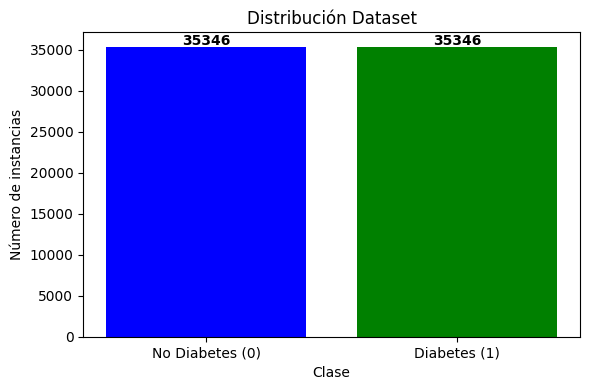

In [4]:
import matplotlib.pyplot as plt

# Contar cuántos hay de cada clase
conteo = df_diabetes['Diabetes_binary'].value_counts()

# Graficar
plt.figure(figsize=(6, 4))
plt.bar(['No Diabetes (0)', 'Diabetes (1)'], conteo.values, color=['blue', 'green'])
plt.title('Distribución Dataset')
plt.xlabel('Clase')
plt.ylabel('Número de instancias')
plt.tight_layout()

# Agregar los números encima de cada barra
for i, valor in enumerate(conteo.values):
    plt.text(i, valor + 200, str(valor), ha='center', fontweight='bold')

plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
import numpy as np

# Separate features (X) and target (y) - X is already DataFrame, y is Series of strings
X = df_diabetes[['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
             'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
             'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
             'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']]
y_raw = df_diabetes['Diabetes_binary']

# Encode the target variable (species) to numerical labels
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)
target_names = le.classes_.tolist() # Store target names for later use

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# One-hot encode the target variable
encoder = OneHotEncoder(sparse_output=False)
y_train_encoded = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_encoded = encoder.transform(y_test.reshape(-1, 1))

print(f"Feature names: {X.columns.tolist()}")
print(f"Target names: {target_names}")
print(f"Shape of X_train_scaled: {X_train_scaled.shape}")
print(f"Shape of y_train_encoded: {y_train_encoded.shape}")
print(f"First 5 one-hot encoded targets in training set:\n{y_train_encoded[:5]}")

Feature names: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']
Target names: [0.0, 1.0]
Shape of X_train_scaled: (56553, 21)
Shape of y_train_encoded: (56553, 2)
First 5 one-hot encoded targets in training set:
[[0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]]


Red neuronal convolutiva:

In [6]:
from tensorflow.keras import optimizers
from tensorflow.keras import models
from tensorflow.keras import layers

model = models.Sequential()
#Entrance X
model.add(layers.Input(shape=(21,)))
model.add(layers.Dense(256,activation='relu'))
#model.add(layers.Dense(128,activation='relu'))

#Sigmoid as activation function for classification
model.add(layers.Dense(1,activation='sigmoid'))

model.summary()

model.compile(loss='binary_crossentropy',
						optimizer=optimizers.Adam(learning_rate=2e-5),
						metrics=['acc','precision','recall'])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         5,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,889 (23.00 KB)

 Trainable params: 5,889 (23.00 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
from tensorflow.keras.callbacks import ModelCheckpoint

In [8]:
%cd "/content/drive/MyDrive/DiabetesModel"
!ls

/content/drive/MyDrive/DiabetesModel
checkpoint.weights.h5
diabetes_binary_5050split_health_indicators_BRFSS2015.csv


In [9]:
checkpoint_path = "/content/drive/MyDrive/DiabetesModel/checkpoint.weights.h5"
checkpoint = ModelCheckpoint(filepath = checkpoint_path,
                             save_freq = "epoch",
                             save_weights_only = True,
                             verbose = 1)

Epoch 1/10
1591/1591 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.5961 - loss: 0.6581 - precision: 0.6235 - recall: 0.4797
Epoch 1: saving model to /content/drive/MyDrive/DiabetesModel/checkpoint.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/DiabetesModel/checkpoint.weights.h5
1591/1591 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - acc: 0.6647 - loss: 0.6099 - precision: 0.6976 - recall: 0.5812 - val_acc: 0.7265 - val_loss: 0.5467 - val_precision: 0.7388 - val_recall: 0.7025
Epoch 2/10
1590/1591 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7328 - loss: 0.5408 - precision: 0.7408 - recall: 0.7208
Epoch 2: saving model to /content/drive/MyDrive/DiabetesModel/checkpoint.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/DiabetesModel/checkpoint.weights.h5
1591/1591 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - acc: 0.7376 - loss: 0.5325 - precision: 0.7386 - recall: 0.7354 - val_acc: 0.7468 - val_loss: 0.5182 - val_precision: 0.7427 - val_recall: 0.7569
Epoch 3/10
1579/1591 ━

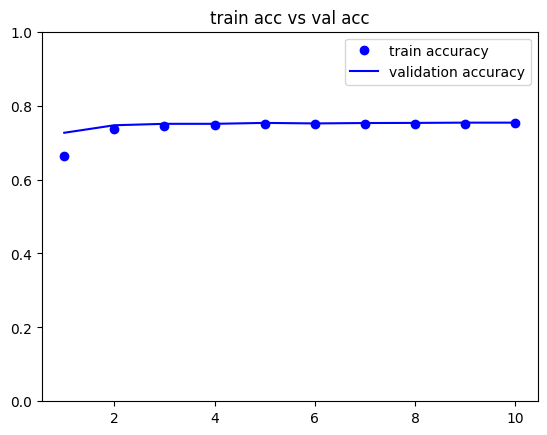

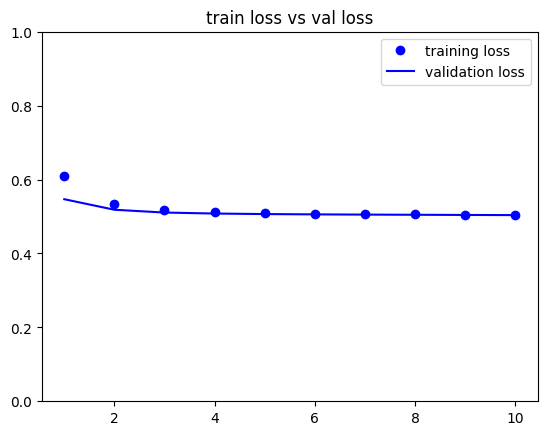

In [10]:
history = model.fit(X_train_scaled, y_train,
				epochs = 10,
				validation_split =.10,
        batch_size=32,
				callbacks = [checkpoint])


acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc)+1)

# Accuracy
plt.plot(epochs, acc, 'bo', label='train accuracy')
plt.plot(epochs, val_acc, 'b', label='validation accuracy')
plt.title('train acc vs val acc')
plt.ylim(0, 1)
plt.legend()

plt.figure()

# Loss Graphic
plt.plot(epochs, loss, 'bo', label='training loss')
plt.plot(epochs, val_loss, 'b', label='validation loss')
plt.title('train loss vs val loss')
plt.ylim(0, 1)
plt.legend()

plt.show()

# **Confusion Matrix**

442/442 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[[5018 2052]
 [1513 5556]]


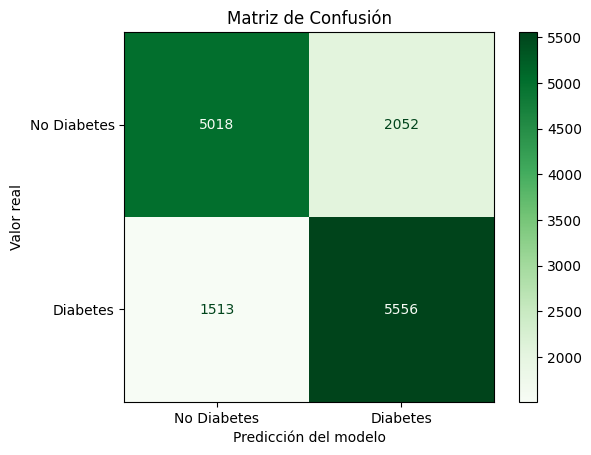

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = y_test

# Matrix
cm = confusion_matrix(y_true, y_pred)
print(cm)

# Graph
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes', 'Diabetes'])
disp.plot(cmap='Greens')
plt.title('Matriz de Confusión')
plt.xlabel('Predicción del modelo')
plt.ylabel('Valor real')
plt.show()

# **Predicción**

In [12]:
model.load_weights("/content/drive/MyDrive/DiabetesModel/checkpoint.weights.h5")

predictions = model.predict(X_test_scaled)

442/442 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [13]:
def plot_paciente(i, predictions_array, y_true):
    true_label = y_true[i]
    pred_prob = predictions_array[i][0]

    if pred_prob > 0.5:
        pred_label = 1
    else:
        pred_label = 0

    label_names = ['No Diabetes', 'Diabetes']

    if pred_label == true_label:
        color = 'green'
    else:
        color = 'red'

    plt.axis('off')
    plt.text(0.5, 0.5, f"{label_names[pred_label]}\n{pred_prob*100:.1f}%\n({label_names[true_label]})",
             ha='center', va='center', fontsize=12, color=color,
             transform=plt.gca().transAxes)


def plot_value_array(i, predictions_array, y_true):
    true_label = y_true[i]
    pred_prob = predictions_array[i][0]

    if pred_prob > 0.5:
        pred_label = 1
    else:
        pred_label = 0

    plt.grid(False)
    plt.xticks([0, 1], ['No Diabetes', 'Diabetes'], rotation=15)
    plt.yticks([])
    thisplot = plt.bar([0, 1], [1 - pred_prob, pred_prob], color='#777777')
    plt.ylim([0, 1])
    thisplot[pred_label].set_color('red')
    thisplot[true_label].set_color('green')

# **Resultados de Predicción**

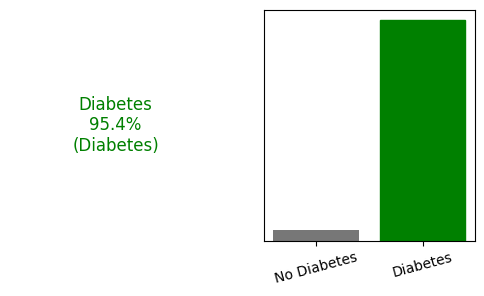

In [14]:
i = 0
plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plot_paciente(i, predictions, y_test)
plt.subplot(1, 2, 2)
plot_value_array(i, predictions, y_test)
plt.show()

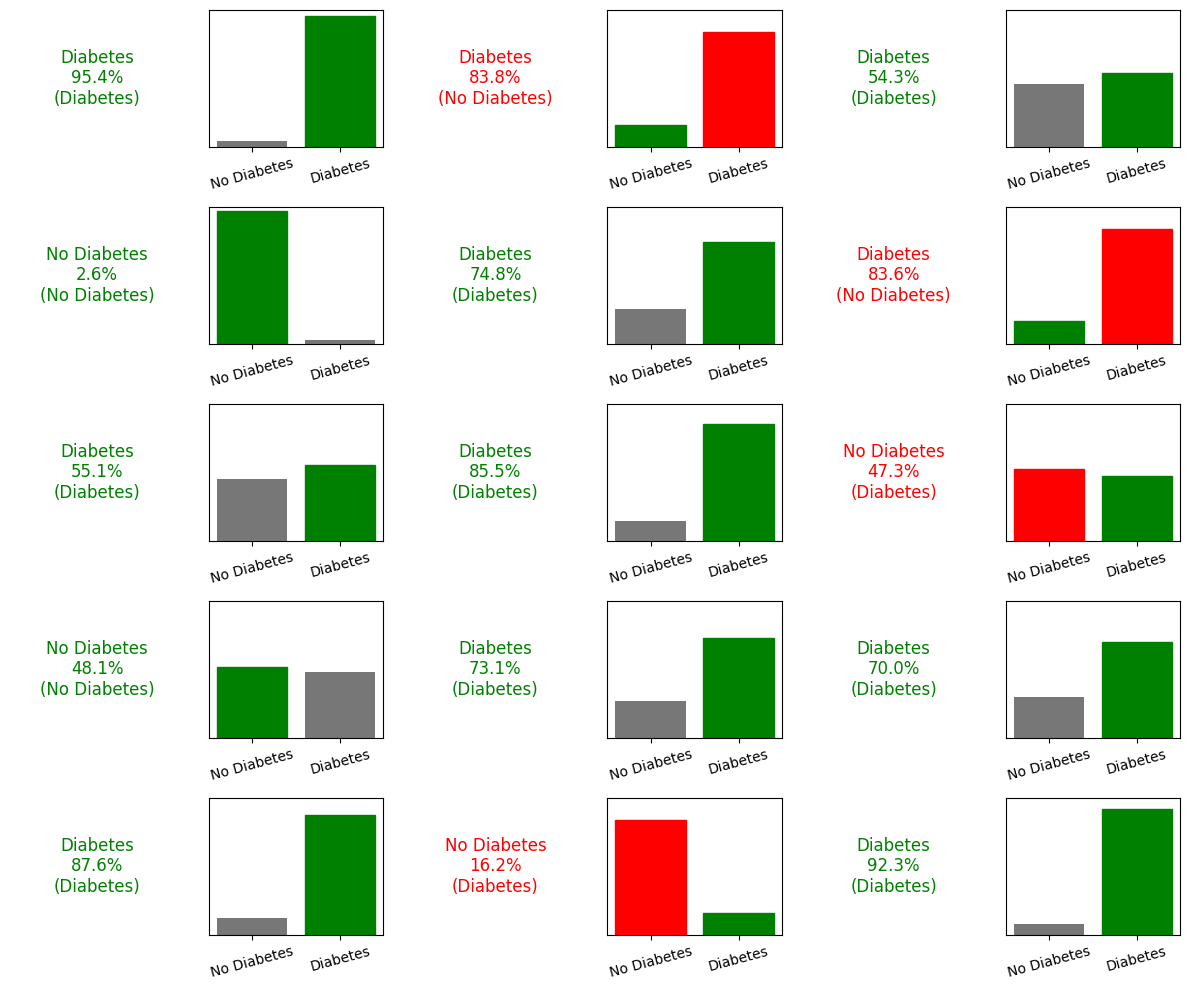

In [15]:
num_rows = 5
num_cols = 3
num_images = num_rows * num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_paciente(i, predictions, y_test)
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_value_array(i, predictions, y_test)
plt.tight_layout()
plt.show()